# Getting the data ready

In [1]:
import pandas as pd

df = pd.read_csv('/content/heart.csv')

In [2]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

In [3]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [4]:
df.drop_duplicates(inplace=True)
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,0,2,120,211,0,0,115,0,1.5,1,0,2,1
733,44,0,2,108,141,0,1,175,0,0.6,1,0,2,1
739,52,1,0,128,255,0,1,161,1,0.0,2,1,3,0
843,59,1,3,160,273,0,0,125,0,0.0,2,0,2,0


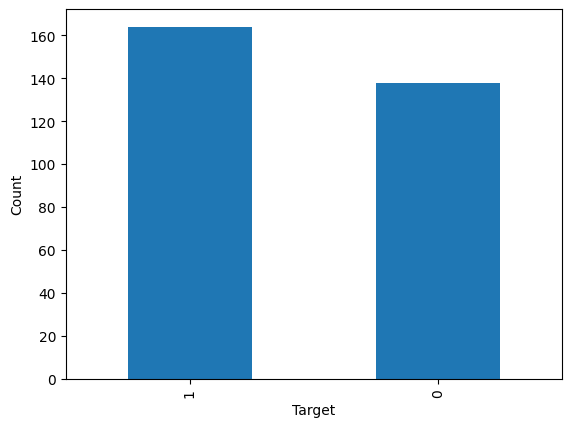

In [5]:
import matplotlib.pyplot as plt

df["target"].value_counts().plot(kind="bar")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

<Axes: >

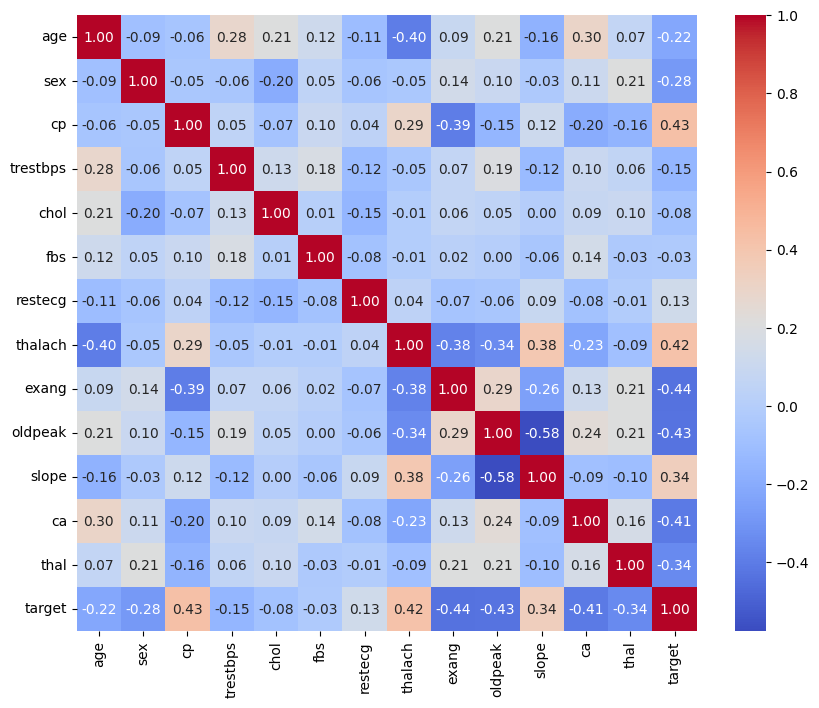

In [6]:
import seaborn as sns

plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

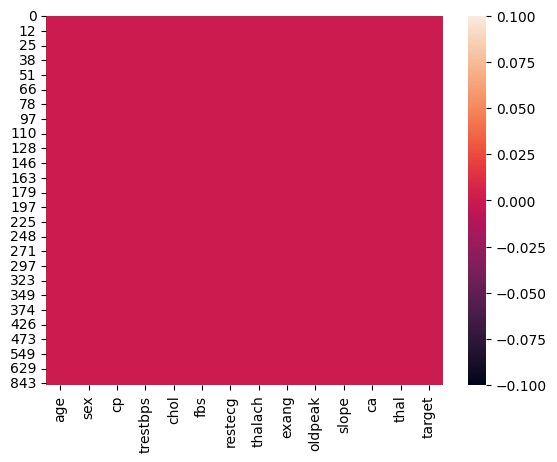

In [7]:
sns.heatmap(df.isnull())

plt.show()

In [8]:
# data preparation
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

smote = SMOTE(random_state=42) # applying SMOTE algorithm
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()

X_train_smote_std = scaler.fit_transform(X_train_smote)
X_test_std = scaler.transform(X_test)

# Biulding models

In [9]:
# with SGDClassifier
from sklearn.linear_model import SGDClassifier

sgd = SGDClassifier(n_jobs=-1,
                    loss='log_loss',
                    random_state=42,
                    learning_rate = 'optimal',
                    early_stopping=True,
                    max_iter=1000,
                    eta0=0.01)

sgd.fit(X_train_smote_std, y_train_smote)
print(sgd.score(X_test_std, y_test), sgd.score(X_train_smote_std, y_train_smote))

0.7252747252747253 0.8305785123966942


In [10]:
# with LogisticRegression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(penalty='l2',
                        solver ='liblinear',
                        C = 1,
                        random_state=42,
                        max_iter=1000,
                        n_jobs=-1)
lr.fit(X_train_smote_std, y_train_smote)
print(lr.score(X_test_std, y_test), lr.score(X_train_smote_std, y_train_smote))

0.8131868131868132 0.8801652892561983


C:\Users\pronk\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\pronk\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


In [11]:
# with GradientBoostingClassifier
from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier(n_estimators=200,
                                 learning_rate=0.05,
                                 max_depth=3,
                                 subsample=0.8,
                                 min_samples_leaf=5,
                                 random_state=42)
# scaling is not needed
gbc.fit(X_train_smote, y_train_smote)
print(gbc.score(X_test, y_test), gbc.score(X_train_smote, y_train_smote))

0.8241758241758241 1.0


In [12]:
# with GradientBoostingClassifier and HalvingRandomSearchCV
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV, StratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline

# SMOTE goes inside the CV pipeline so synthetic samples don't leak across folds
pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('gbc', GradientBoostingClassifier(random_state=42))
])

params = {'gbc__n_estimators': [50, 100, 200],
          'gbc__learning_rate': [0.1, 0.05, 0.01],
          'gbc__max_depth': [2, 3, 4],
          'gbc__subsample': [0.7, 0.8, 1.0],
          'gbc__min_samples_leaf': [1, 5, 10]}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

hrs = HalvingRandomSearchCV(estimator=pipe,
                            param_distributions=params,
                            n_jobs=-1,
                            cv=cv,
                            scoring='accuracy',
                            factor=3,
                            min_resources=100,
                            random_state=42,
                            n_candidates='exhaust').fit(X_train, y_train)

hrs.best_params_, hrs.score(X_test, y_test), hrs.score(X_train, y_train)

({'gbc__subsample': 0.7,
  'gbc__n_estimators': 100,
  'gbc__min_samples_leaf': 10,
  'gbc__max_depth': 2,
  'gbc__learning_rate': 0.05},
 0.8241758241758241,
 0.9004739336492891)

In [ ]:
!pip install catboost

In [13]:
# with CatBoostClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split as tts

cbc_params = dict(learning_rate=0.03, max_depth=4, l2_leaf_reg=10, subsample=0.8, random_seed=42)

X_tr, X_val, y_tr, y_val = tts(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

cbc = CatBoostClassifier(n_estimators=1000, verbose=100, early_stopping_rounds=50, **cbc_params)
cbc.fit(X_tr, y_tr, eval_set=(X_val, y_val))

print('best_iteration:', cbc.get_best_iteration())
print(cbc.score(X_test, y_test), cbc.score(X_train, y_train))

0:	learn: 0.6806611	test: 0.6809133	best: 0.6809133 (0)	total: 140ms	remaining: 2m 20s
100:	learn: 0.2734260	test: 0.3779137	best: 0.3764337 (96)	total: 220ms	remaining: 1.96s
200:	learn: 0.1948038	test: 0.3757460	best: 0.3721984 (180)	total: 298ms	remaining: 1.18s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.3721984481
bestIteration = 180

Shrink model to first 181 iterations.


best_iteration: 180
0.8461538461538461 0.933649289099526


# Evaluation

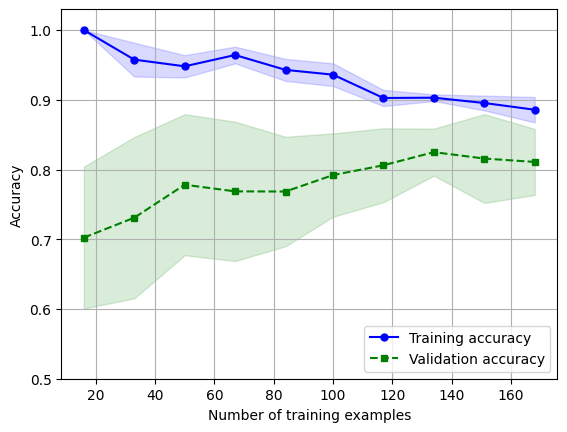

In [14]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import learning_curve, StratifiedKFold

# fixed tree count, no early_stopping_rounds, so learning_curve can clone/refit this estimator without an eval_set
cbc_for_curve = CatBoostClassifier(n_estimators=cbc.tree_count_, verbose=False, **cbc_params)

train_sizes, train_scores, test_scores = learning_curve(
    estimator=cbc_for_curve,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)


plt.plot(
    train_sizes,
    train_mean,
    color='blue',
    marker='o',
    markersize=5,
    label='Training accuracy'
)

plt.fill_between(
    train_sizes,
    train_mean + train_std,
    train_mean - train_std,
    alpha=0.15,
    color='blue'
)

plt.plot(
    train_sizes,
    test_mean,
    color='green',
    linestyle='--',
    marker='s',
    markersize=5,
    label='Validation accuracy'
)

plt.fill_between(
    train_sizes,
    test_mean + test_std,
    test_mean - test_std,
    alpha=0.15,
    color='green'
)

plt.grid()
plt.xlabel('Number of training examples')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.ylim([0.5, 1.03])

plt.show()

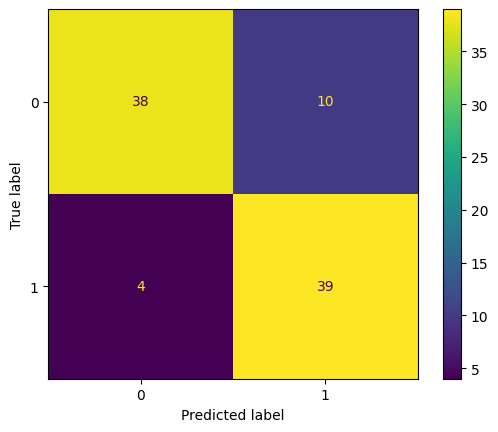

In [15]:
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

y_preds = cbc.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=y_preds)

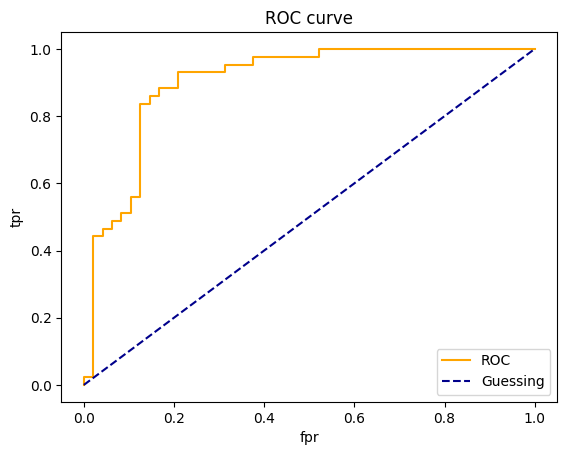

In [16]:
from sklearn.metrics import roc_curve

y_probs = cbc.predict_proba(X_test)
y_probs[:10]

y_probs_positive = y_probs[:, 1]
y_probs_positive[:10]

fpr, tpr, thresholds = roc_curve(y_test, y_probs_positive)


plt.plot(fpr, tpr, color='orange', label = 'ROC')
plt.plot([0, 1], [0, 1], color = 'darkblue', linestyle = '--', label = 'Guessing')

plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title('ROC curve')
plt.legend()
plt.show()

In [17]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_probs_positive)

0.9021317829457365

In [18]:
from sklearn.metrics import auc
auc(fpr, tpr)

0.9021317829457365

In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.90      0.79      0.84        48
           1       0.80      0.91      0.85        43

    accuracy                           0.85        91
   macro avg       0.85      0.85      0.85        91
weighted avg       0.85      0.85      0.85        91



In [20]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline

# honest overall estimate: 5-fold CV with SMOTE fit inside each fold, since a single 91-row test split is noisy
cv_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('cbc', CatBoostClassifier(n_estimators=cbc.tree_count_, verbose=False, **cbc_params))
])

cv_scores = cross_val_score(cv_pipe, X, y,
                            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                            scoring='accuracy', n_jobs=-1)
print(cv_scores, cv_scores.mean(), cv_scores.std())

[0.7704918  0.83606557 0.8        0.9        0.8       ] 0.8213114754098362 0.044498459219209315


# Top model features

<Axes: title={'center': 'feature importance'}>

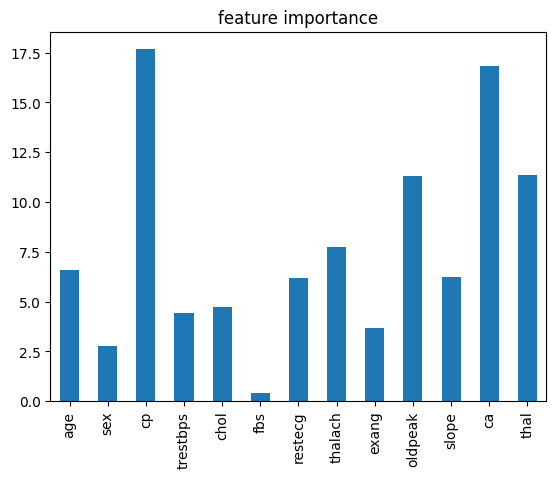

In [21]:
feature_dict = dict(zip(X.columns, cbc.feature_importances_))

feature_X = pd.DataFrame(feature_dict, index=[0])
feature_X.T.plot.bar(title='feature importance', legend=False)

# Save the model

In [22]:
import joblib
joblib.dump(cbc, 'cbc.joblib')

['cbc.joblib']